# Análise Exploratória de Dados (EDA)
## Dataset: Conversation Transcripts

Este notebook apresenta uma análise exploratória completa do dataset de transcrições de conversas.

## 1. Importação de Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import warnings

warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_palette('husl')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento dos Dados

In [3]:
# Carregar o dataset
df = pd.read_csv('conversationtranscripts.csv')

print(f"Dataset carregado com sucesso!")
print(f"\nDimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")

Dataset carregado com sucesso!

Dimensões do dataset: 3165 linhas x 15 colunas


## 3. Visão Geral do Dataset

In [4]:
# Primeiras linhas
print("=" * 80)
print("PRIMEIRAS 5 LINHAS DO DATASET")
print("=" * 80)
df.head()

PRIMEIRAS 5 LINHAS DO DATASET


,utcconversiontimezonecode,schemaversion,content,conversationstarttime,conversationtranscriptid,metadata,name,importsequencenumber,timezoneruleversionnumber,statuscode,schematype,statecode,versionnumber,owningbusinessunit,bot_conversationtranscriptid.schemaname
0,NaN,0.2.2,"{""activities"":[{""valueType"":""ConversationInfo"",""type"":""trace"",""timestamp"":1770063347,""from"":{""id...",2026-02-02 20:15:47.0000000,b83d7cc8-98bc-4312-9007-e956b25bbdfd,"{""BotId"":""b4ef799f-1225-34ce-36a4-48c07c284ee3"",""AADTenantId"":""0e36c668-f89c-4391-b4e0-d7a789672...",a:1kQgXNehXFTljzQ0ElMJB9nZWmPffWSeO9-gPn2b9sSk-0igyUDCsZ0F4g7Uqr8IWi2wPadgALx9pplzvacGZUfzMAWKfK...,NaN,4,1,powervirtualagents,0,46745765,4c20ed97-edde-ea11-a815-000d3ac172ff,coe_copilotoRh
1,NaN,0.2.2,"{""activities"":[{""valueType"":""ConversationInfo"",""type"":""trace"",""timestamp"":1770063276,""from"":{""id...",2026-02-02 20:14:36.0000000,f99d31b6-86a7-48fc-b1f8-039ec9b095c7,"{""BotId"":""b4ef799f-1225-34ce-36a4-48c07c284ee3"",""AADTenantId"":""0e36c668-f89c-4391-b4e0-d7a789672...",a:1xlkESZre6BqloKmM9tYh0zPVtULGbnSBqTVlIWtmxD9YkbvjykOMpgNHfGuOnsB3BIT61ehu31uGlx9DSsPTwsUUaWD_G...,NaN,4,1,powervirtualagents,0,46745578,4c20ed97-edde-ea11-a815-000d3ac172ff,coe_copilotoRh
2,NaN,0.2.2,"{""activities"":[{""valueType"":""ConversationInfo"",""type"":""trace"",""timestamp"":1770062566,""from"":{""id...",2026-02-02 20:02:46.0000000,fac93155-bcee-4e9f-b7db-e5efd00ba0cf,"{""BotId"":""b4ef799f-1225-34ce-36a4-48c07c284ee3"",""AADTenantId"":""0e36c668-f89c-4391-b4e0-d7a789672...",a:13rqs3N8WdeG4n2sx8f0Aux90cBLlqjUqlRVRsR4y_BJo6zc89_jtTNmiksXwaRB_brmGqrqXB7rdZLcJ5DntqNHz9Cgb1...,NaN,4,1,powervirtualagents,0,46745415,4c20ed97-edde-ea11-a815-000d3ac172ff,coe_copilotoRh
3,NaN,0.2.2,"{""activities"":[{""valueType"":""ConversationInfo"",""type"":""trace"",""timestamp"":1770062321,""from"":{""id...",2026-02-02 19:58:41.0000000,3733b92f-3539-4482-8713-6675625cf2b4,"{""BotId"":""b4ef799f-1225-34ce-36a4-48c07c284ee3"",""AADTenantId"":""0e36c668-f89c-4391-b4e0-d7a789672...",a:1MzUjgLp8_ZJxYYcRgveNK9tw_SL2nrxR7EMu6qZAdmCuBzHTP08L8sCSh7Y-YJ6Pln1I9b9DhNw585pxbmyaGPBnY02zw...,NaN,4,1,powervirtualagents,0,46745338,4c20ed97-edde-ea11-a815-000d3ac172ff,coe_copilotoRh
4,NaN,0.2.2,"{""activities"":[{""valueType"":""ConversationInfo"",""type"":""trace"",""timestamp"":1770061884,""from"":{""id...",2026-02-02 19:51:24.0000000,58af68b5-a4f3-495c-b92e-bd51daef0d46,"{""BotId"":""b4ef799f-1225-34ce-36a4-48c07c284ee3"",""AADTenantId"":""0e36c668-f89c-4391-b4e0-d7a789672...",a:16SUNFChVULJPMdhN0vHofmXB9HgRw3_ImFocelAhQI7rJDrzopb5UBvsLXqvh4YrJioaYmQ0KfyHboNXFqqhSk1IXRASH...,NaN,4,1,powervirtualagents,0,46745069,4c20ed97-edde-ea11-a815-000d3ac172ff,coe_copilotoRh


In [5]:
# Últimas linhas
print("=" * 80)
print("ÚLTIMAS 5 LINHAS DO DATASET")
print("=" * 80)
df.tail()

ÚLTIMAS 5 LINHAS DO DATASET


,utcconversiontimezonecode,schemaversion,content,conversationstarttime,conversationtranscriptid,metadata,name,importsequencenumber,timezoneruleversionnumber,statuscode,schematype,statecode,versionnumber,owningbusinessunit,bot_conversationtranscriptid.schemaname
3160,NaN,0.2.2,"{""activities"":[{""valueType"":""ConversationInfo"",""type"":""trace"",""timestamp"":1767332434,""from"":{""id...",2026-01-02 05:40:34.0000000,66f6c852-9a25-4e0d-a008-f89470f6626e,"{""BotId"":""b4ef799f-1225-34ce-36a4-48c07c284ee3"",""AADTenantId"":""0e36c668-f89c-4391-b4e0-d7a789672...",a:1oCbjbV9SpNAjfvSdNwnB569jiYdwPp3c16U0zOK0UXc5aeJLCuyB-Bvt8ypDf1JHKwNCmeDZeet8kwtuh4dX9IQ,NaN,4,1,powervirtualagents,0,45675155,4c20ed97-edde-ea11-a815-000d3ac172ff,coe_copilotoRh
3161,NaN,0.2.2,"{""activities"":[{""valueType"":""ConversationInfo"",""type"":""trace"",""timestamp"":1767328214,""from"":{""id...",2026-01-02 04:30:14.0000000,a9865a0f-8f53-4c85-90cd-0c37644f2f77,"{""BotId"":""b4ef799f-1225-34ce-36a4-48c07c284ee3"",""AADTenantId"":""0e36c668-f89c-4391-b4e0-d7a789672...",a:1oCbjbV9SpNAjfvSdNwnB569jiYdwPp3c16U0zOK0UXc5aeJLCuyB-Bvt8ypDf1JHKwNCmeDZeet8kwtuh4dX9IQ,NaN,4,1,powervirtualagents,0,45674339,4c20ed97-edde-ea11-a815-000d3ac172ff,coe_copilotoRh
3162,NaN,0.2.2,"{""activities"":[{""valueType"":""ConversationInfo"",""type"":""trace"",""timestamp"":1767327684,""from"":{""id...",2026-01-02 04:21:24.0000000,4044f9b6-fab2-4742-bdb3-e2b8c4e6c682,"{""BotId"":""b4ef799f-1225-34ce-36a4-48c07c284ee3"",""AADTenantId"":""0e36c668-f89c-4391-b4e0-d7a789672...",a:1U2UERUxYpAJoxLkquaMX3PIy-zp_sDyrrdAyhJMo6O9cwzq_iwcgQ6Q3R5HwZtGSmDWQoZQ-dItv9ZiOJ2H9S4U,NaN,4,1,powervirtualagents,0,45674258,4c20ed97-edde-ea11-a815-000d3ac172ff,coe_copilotoRh
3163,NaN,0.2.2,"{""activities"":[{""valueType"":""ConversationInfo"",""type"":""trace"",""timestamp"":1767319001,""from"":{""id...",2026-01-02 01:56:41.0000000,8f30e2ca-48ff-4afd-a96b-4c84ab5efa07,"{""BotId"":""b4ef799f-1225-34ce-36a4-48c07c284ee3"",""AADTenantId"":""0e36c668-f89c-4391-b4e0-d7a789672...",a:1tNCeJYpCazu8e_DteOoxPxHrJP1J_miIcSEB-G4lV88LHlIRelehUrur-koEzee6JGGiVuAZt7k8bw-kCwM6v2T,NaN,4,1,powervirtualagents,0,45672648,4c20ed97-edde-ea11-a815-000d3ac172ff,coe_copilotoRh
3164,NaN,0.2.2,"{""activities"":[{""valueType"":""ConversationInfo"",""type"":""trace"",""timestamp"":1767314782,""from"":{""id...",2026-01-02 00:46:22.0000000,ac7904d8-e16f-46c7-b0de-88026e759faa,"{""BotId"":""b4ef799f-1225-34ce-36a4-48c07c284ee3"",""AADTenantId"":""0e36c668-f89c-4391-b4e0-d7a789672...",a:19-SFNEtgyNuhs13x3TEUiJ2hqb4zoXImBfuHtfXjjVgnJCNfPRffxvaC7FkGCLlHt-dIIYLnX_zJt3RESsQq4Mx,NaN,4,1,powervirtualagents,0,45672048,4c20ed97-edde-ea11-a815-000d3ac172ff,coe_copilotoRh


In [6]:
# Informações do dataset
print("=" * 80)
print("INFORMAÇÕES GERAIS DO DATASET")
print("=" * 80)
df.info()

INFORMAÇÕES GERAIS DO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3165 entries, 0 to 3164
Data columns (total 15 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   utcconversiontimezonecode                0 non-null      float64
 1   schemaversion                            3165 non-null   object 
 2   content                                  3165 non-null   object 
 3   conversationstarttime                    3165 non-null   object 
 4   conversationtranscriptid                 3165 non-null   object 
 5   metadata                                 3165 non-null   object 
 6   name                                     3165 non-null   object 
 7   importsequencenumber                     0 non-null      float64
 8   timezoneruleversionnumber                3165 non-null   int64  
 9   statuscode                               3165 non-null   int64  
 10  schematype        

In [7]:
# Nomes das colunas
print("=" * 80)
print("COLUNAS DO DATASET")
print("=" * 80)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

COLUNAS DO DATASET
 1. utcconversiontimezonecode
 2. schemaversion
 3. content
 4. conversationstarttime
 5. conversationtranscriptid
 6. metadata
 7. name
 8. importsequencenumber
 9. timezoneruleversionnumber
10. statuscode
11. schematype
12. statecode
13. versionnumber
14. owningbusinessunit
15. bot_conversationtranscriptid.schemaname


## 4. Análise de Tipos de Dados

In [8]:
# Tipos de dados por coluna
print("=" * 80)
print("TIPOS DE DADOS POR COLUNA")
print("=" * 80)

tipos_df = pd.DataFrame({
    'Coluna': df.columns,
    'Tipo': df.dtypes.values,
    'Valores Únicos': [df[col].nunique() for col in df.columns],
    'Valores Nulos': df.isnull().sum().values,
    '% Nulos': (df.isnull().sum().values / len(df) * 100).round(2)
})

tipos_df

TIPOS DE DADOS POR COLUNA


,Coluna,Tipo,Valores Únicos,Valores Nulos,% Nulos
0,utcconversiontimezonecode,float64,0,3165,100.0
1,schemaversion,object,1,0,0.0
2,content,object,3165,0,0.0
3,conversationstarttime,object,3137,0,0.0
4,conversationtranscriptid,object,3165,0,0.0
5,metadata,object,5,0,0.0
6,name,object,2180,0,0.0
7,importsequencenumber,float64,0,3165,100.0
8,timezoneruleversionnumber,int64,1,0,0.0
9,statuscode,int64,1,0,0.0


## 5. Análise de Valores Nulos


Colunas com valores nulos: 2


,Valores Nulos,Percentual (%)
utcconversiontimezonecode,3165,100.0
importsequencenumber,3165,100.0


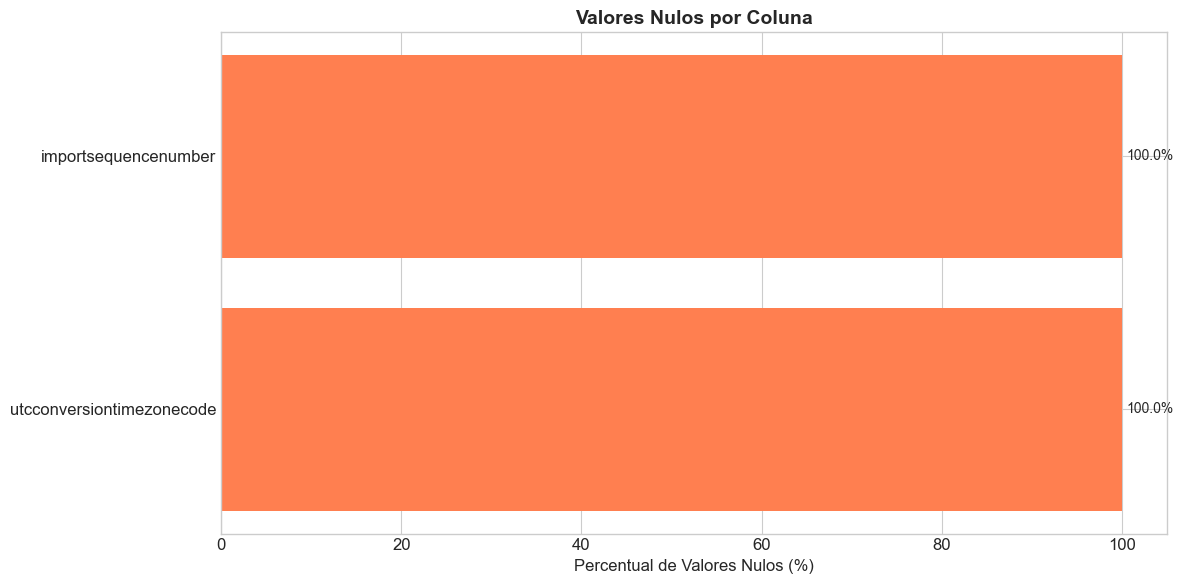

In [9]:
# Visualização de valores nulos
nulos = df.isnull().sum()
nulos_percent = (nulos / len(df) * 100).round(2)

nulos_df = pd.DataFrame({
    'Valores Nulos': nulos,
    'Percentual (%)': nulos_percent
}).sort_values('Valores Nulos', ascending=False)

# Filtrar apenas colunas com valores nulos
nulos_df_filtrado = nulos_df[nulos_df['Valores Nulos'] > 0]

if len(nulos_df_filtrado) > 0:
    print(f"\nColunas com valores nulos: {len(nulos_df_filtrado)}")
    display(nulos_df_filtrado)
    
    # Gráfico de valores nulos
    fig, ax = plt.subplots(figsize=(12, max(6, len(nulos_df_filtrado) * 0.4)))
    bars = ax.barh(nulos_df_filtrado.index, nulos_df_filtrado['Percentual (%)'], color='coral')
    ax.set_xlabel('Percentual de Valores Nulos (%)')
    ax.set_title('Valores Nulos por Coluna', fontsize=14, fontweight='bold')
    
    # Adicionar valores nas barras
    for bar, val in zip(bars, nulos_df_filtrado['Percentual (%)']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}%', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ Nenhum valor nulo encontrado no dataset!")

## 6. Estatísticas Descritivas

In [10]:
# Estatísticas para colunas numéricas
print("=" * 80)
print("ESTATÍSTICAS DESCRITIVAS - COLUNAS NUMÉRICAS")
print("=" * 80)
df.describe()

ESTATÍSTICAS DESCRITIVAS - COLUNAS NUMÉRICAS


,utcconversiontimezonecode,importsequencenumber,timezoneruleversionnumber,statuscode,statecode,versionnumber
count,0.0,0.0,3165.0,3165.0,3165.0,3.165000e+03
mean,NaN,NaN,4.0,1.0,0.0,4.619654e+07
std,NaN,NaN,0.0,0.0,0.0,3.315258e+05
min,NaN,NaN,4.0,1.0,0.0,4.567205e+07
25%,NaN,NaN,4.0,1.0,0.0,4.587913e+07
50%,NaN,NaN,4.0,1.0,0.0,4.618319e+07
75%,NaN,NaN,4.0,1.0,0.0,4.652267e+07
max,NaN,NaN,4.0,1.0,0.0,4.674576e+07


In [11]:
# Estatísticas para colunas categóricas
print("=" * 80)
print("ESTATÍSTICAS DESCRITIVAS - COLUNAS CATEGÓRICAS")
print("=" * 80)
df.describe(include='object')

ESTATÍSTICAS DESCRITIVAS - COLUNAS CATEGÓRICAS


,schemaversion,content,conversationstarttime,conversationtranscriptid,metadata,name,schematype,owningbusinessunit,bot_conversationtranscriptid.schemaname
count,3165,3165,3165,3165,3165,3165,3165,3165,3165
unique,1,3165,3137,3165,5,2180,1,1,4
top,0.2.2,"{""activities"":[{""valueType"":""ConversationInfo"",""type"":""trace"",""timestamp"":1770063347,""from"":{""id...",2026-02-02 14:04:40.0000000,b83d7cc8-98bc-4312-9007-e956b25bbdfd,"{""BotId"":""b4ef799f-1225-34ce-36a4-48c07c284ee3"",""AADTenantId"":""0e36c668-f89c-4391-b4e0-d7a789672...",a:1OjUhHend4Uo7X6SCvl-Kwf1vt7Y5Rtjj2XmnVH2z5u2i0bES9V2KFlY0QljMVaYEU4UF4CByKcNQfyomQBzRSLGh4peus...,powervirtualagents,4c20ed97-edde-ea11-a815-000d3ac172ff,coe_copilotoRh
freq,3165,1,3,1,2994,23,3165,3165,2995


## 7. Análise de Colunas Categóricas

In [12]:
# Identificar colunas categóricas com poucos valores únicos
categorical_cols = []

for col in df.columns:
    n_unique = df[col].nunique()
    if n_unique <= 20 and df[col].dtype == 'object':
        categorical_cols.append(col)
    elif n_unique <= 20 and df[col].dtype in ['int64', 'float64']:
        categorical_cols.append(col)

print(f"Colunas categóricas identificadas (até 20 valores únicos): {len(categorical_cols)}")
print(categorical_cols)

Colunas categóricas identificadas (até 20 valores únicos): 10
['utcconversiontimezonecode', 'schemaversion', 'metadata', 'importsequencenumber', 'timezoneruleversionnumber', 'statuscode', 'schematype', 'statecode', 'owningbusinessunit', 'bot_conversationtranscriptid.schemaname']


In [13]:
# Distribuição de valores para colunas categóricas
for col in categorical_cols:
    print("\n" + "=" * 60)
    print(f"DISTRIBUIÇÃO: {col}")
    print("=" * 60)
    
    value_counts = df[col].value_counts(dropna=False)
    value_percent = (value_counts / len(df) * 100).round(2)
    
    dist_df = pd.DataFrame({
        'Contagem': value_counts,
        'Percentual (%)': value_percent
    })
    display(dist_df)


DISTRIBUIÇÃO: utcconversiontimezonecode


,Contagem,Percentual (%)
utcconversiontimezonecode,,
NaN,3165,100.0



DISTRIBUIÇÃO: schemaversion


,Contagem,Percentual (%)
schemaversion,,
0.2.2,3165,100.0



DISTRIBUIÇÃO: metadata


...

,Contagem,Percentual (%)
statecode,,
0,3165,100.0



DISTRIBUIÇÃO: owningbusinessunit


,Contagem,Percentual (%)
owningbusinessunit,,
4c20ed97-edde-ea11-a815-000d3ac172ff,3165,100.0



DISTRIBUIÇÃO: bot_conversationtranscriptid.schemaname


,Contagem,Percentual (%)
bot_conversationtranscriptid.schemaname,,
coe_copilotoRh,2995,94.63
cr61e_agenteVirtualOptMove,101,3.19
crecd_lia,64,2.02
copilots_header_f8a68,5,0.16


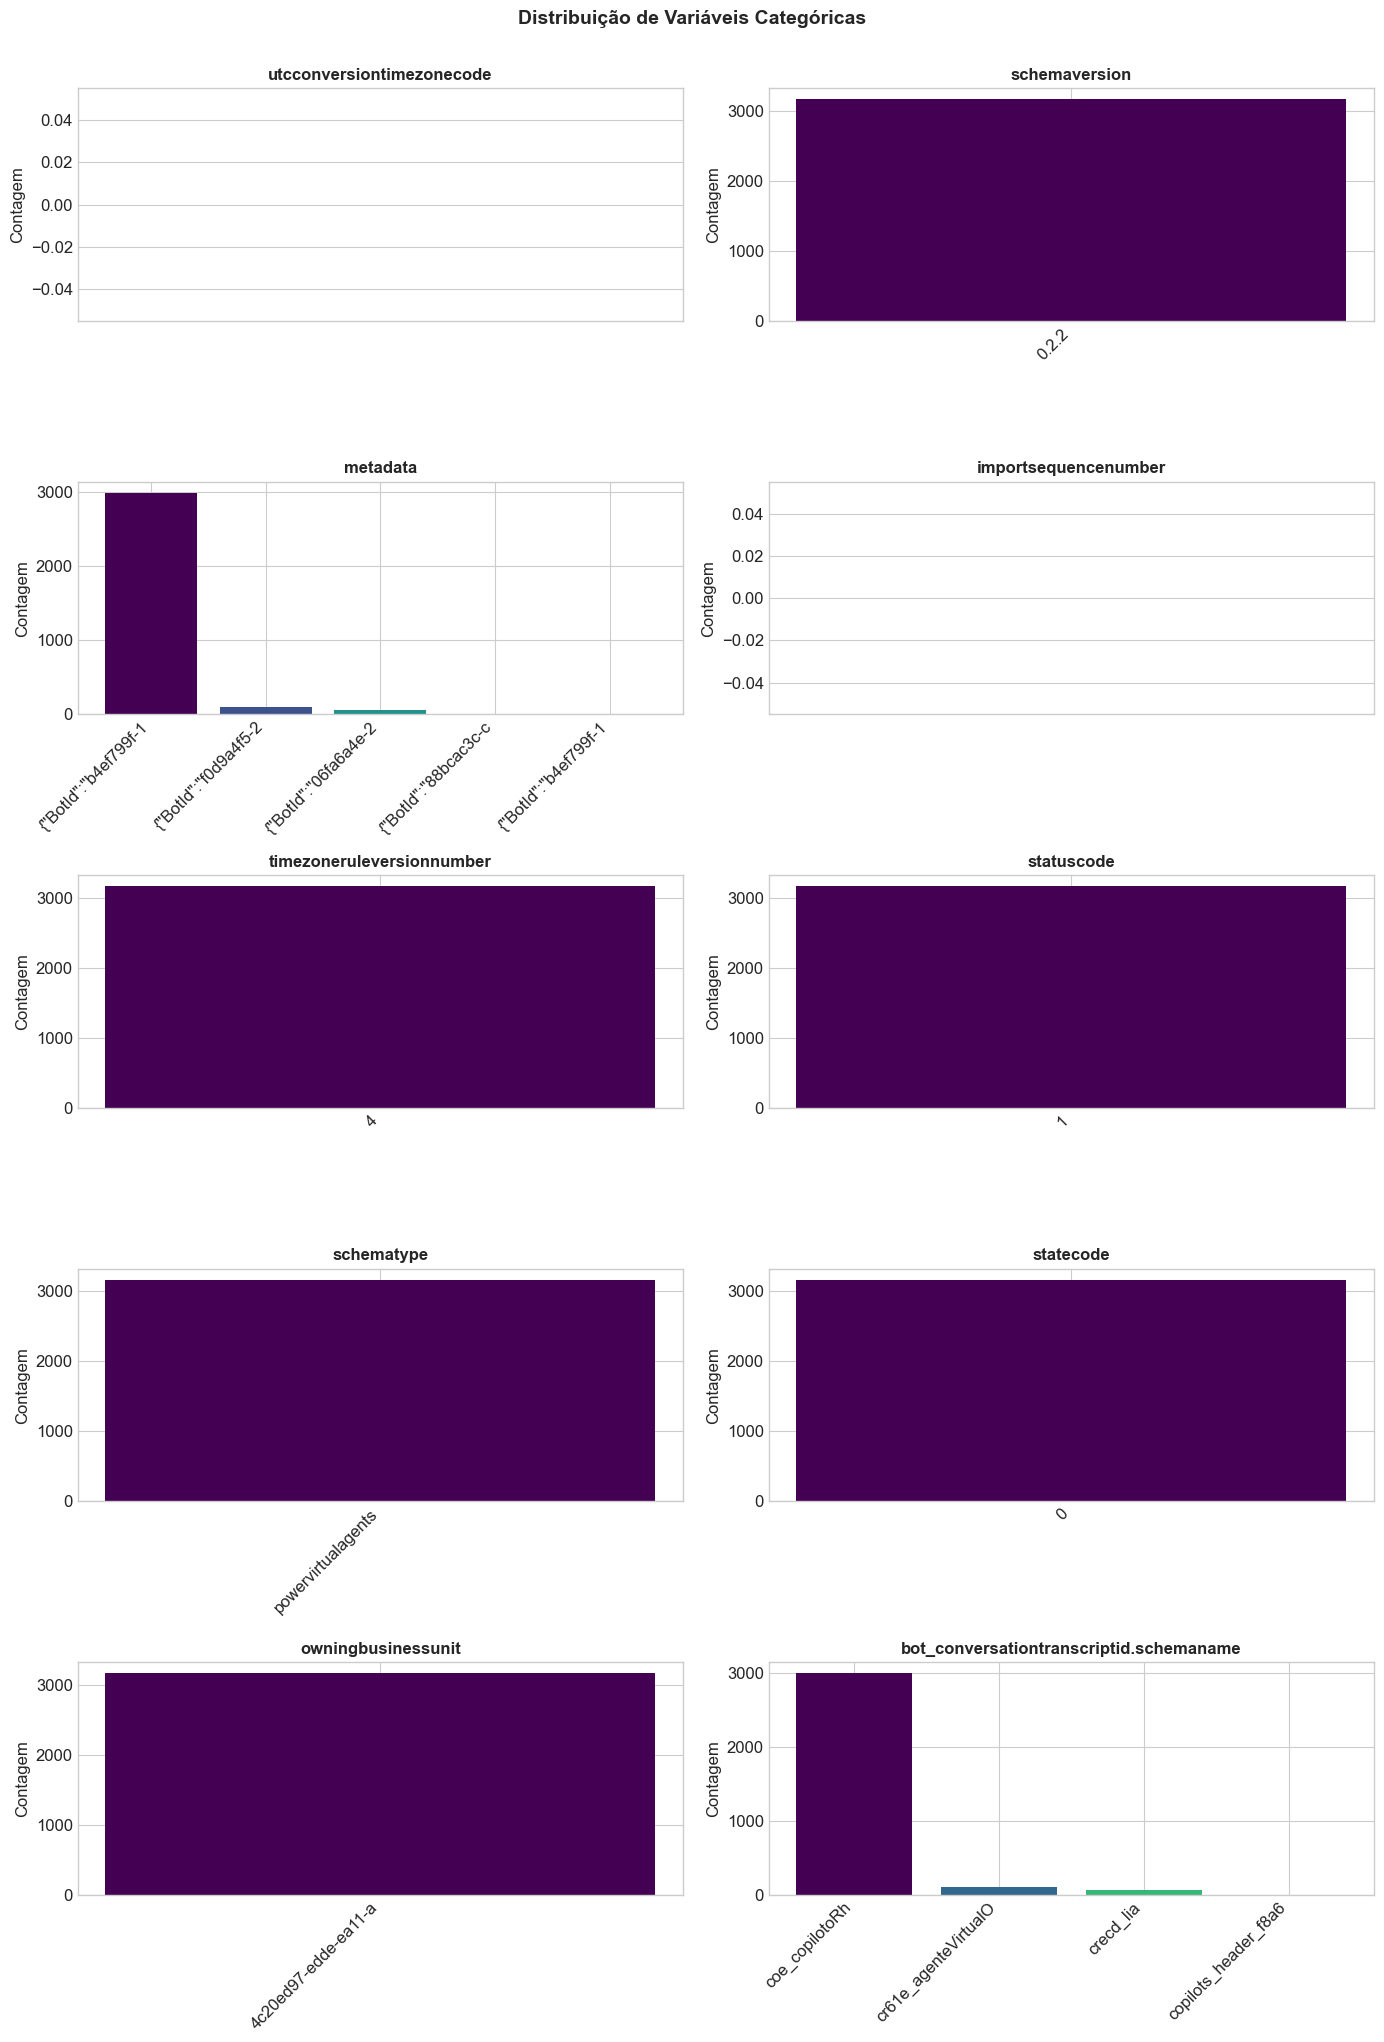

In [14]:
# Visualização das colunas categóricas
if len(categorical_cols) > 0:
    n_cols = 2
    n_rows = (len(categorical_cols) + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()
    
    for idx, col in enumerate(categorical_cols):
        if idx < len(axes):
            value_counts = df[col].value_counts().head(10)
            axes[idx].bar(range(len(value_counts)), value_counts.values, color=plt.cm.viridis(np.linspace(0, 1, len(value_counts))))
            axes[idx].set_xticks(range(len(value_counts)))
            axes[idx].set_xticklabels([str(x)[:20] for x in value_counts.index], rotation=45, ha='right')
            axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
            axes[idx].set_ylabel('Contagem')
    
    # Esconder eixos extras
    for idx in range(len(categorical_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle('Distribuição de Variáveis Categóricas', y=1.02, fontsize=14, fontweight='bold')
    plt.show()

## 8. Análise Temporal

In [15]:
# Verificar se existe coluna de data/hora
date_cols = ['conversationstarttime', 'createdon', 'modifiedon']
date_cols_found = [col for col in date_cols if col in df.columns]

print(f"Colunas de data encontradas: {date_cols_found}")

# Converter colunas de data
for col in date_cols_found:
    try:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f"\n{col}: convertido para datetime")
        print(f"  - Primeiro registro: {df[col].min()}")
        print(f"  - Último registro: {df[col].max()}")
        print(f"  - Período: {(df[col].max() - df[col].min()).days} dias")
    except Exception as e:
        print(f"Erro ao converter {col}: {e}")

Colunas de data encontradas: ['conversationstarttime']

conversationstarttime: convertido para datetime
  - Primeiro registro: 2026-01-02 00:46:22
  - Último registro: 2026-02-02 20:15:47
  - Período: 31 dias


In [16]:
# Análise temporal - Distribuição por período
if 'conversationstarttime' in df.columns and df['conversationstarttime'].dtype == 'datetime64[ns]':
    # Extrair componentes de data
    df['ano'] = df['conversationstarttime'].dt.year
    df['mes'] = df['conversationstarttime'].dt.month
    df['dia_semana'] = df['conversationstarttime'].dt.day_name()
    df['hora'] = df['conversationstarttime'].dt.hour
    df['data'] = df['conversationstarttime'].dt.date
    
    print("Componentes temporais extraídos: ano, mes, dia_semana, hora, data")

Componentes temporais extraídos: ano, mes, dia_semana, hora, data


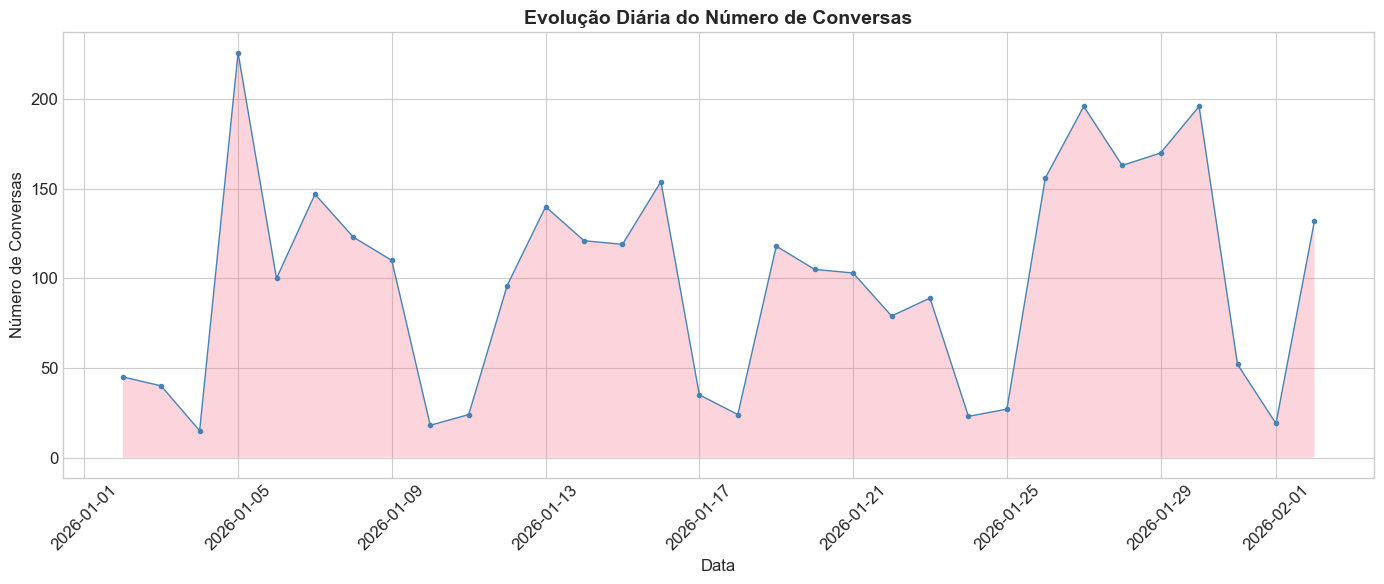


Estatísticas diárias:
  - Média de conversas/dia: 98.9
  - Máximo de conversas/dia: 226
  - Mínimo de conversas/dia: 15
  - Desvio padrão: 60.3


In [17]:
# Gráfico: Conversas por dia
if 'data' in df.columns:
    conversas_por_dia = df.groupby('data').size().reset_index(name='contagem')
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(conversas_por_dia['data'], conversas_por_dia['contagem'], 
            marker='o', markersize=3, linewidth=1, color='steelblue')
    ax.fill_between(conversas_por_dia['data'], conversas_por_dia['contagem'], alpha=0.3)
    ax.set_xlabel('Data')
    ax.set_ylabel('Número de Conversas')
    ax.set_title('Evolução Diária do Número de Conversas', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Estatísticas
    print(f"\nEstatísticas diárias:")
    print(f"  - Média de conversas/dia: {conversas_por_dia['contagem'].mean():.1f}")
    print(f"  - Máximo de conversas/dia: {conversas_por_dia['contagem'].max()}")
    print(f"  - Mínimo de conversas/dia: {conversas_por_dia['contagem'].min()}")
    print(f"  - Desvio padrão: {conversas_por_dia['contagem'].std():.1f}")

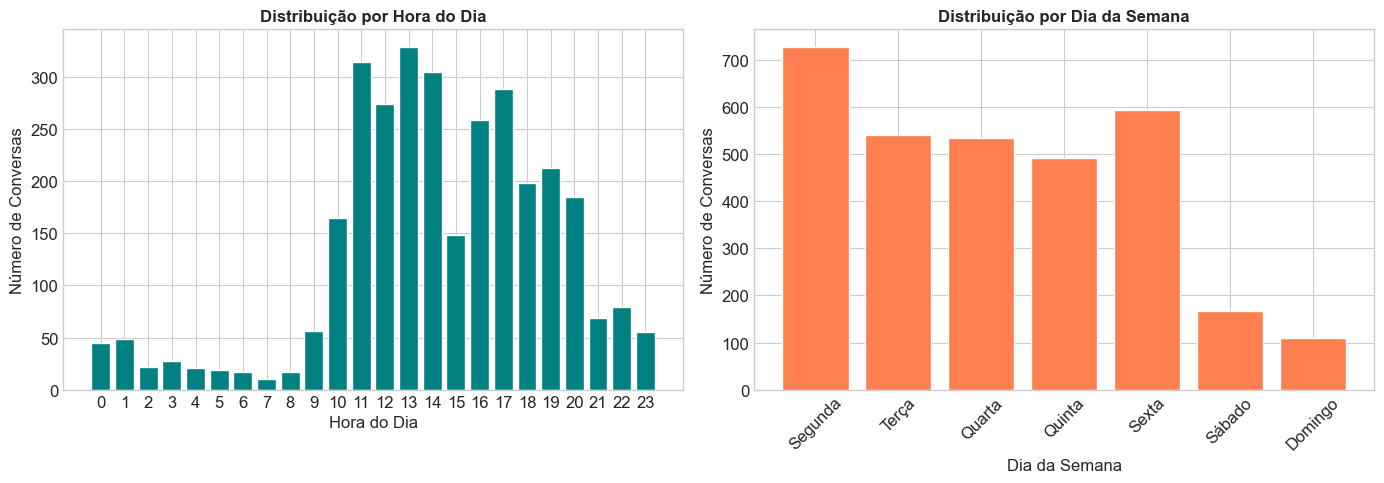

In [18]:
# Gráfico: Distribuição por hora do dia
if 'hora' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Por hora
    conversas_por_hora = df['hora'].value_counts().sort_index()
    axes[0].bar(conversas_por_hora.index, conversas_por_hora.values, color='teal', edgecolor='white')
    axes[0].set_xlabel('Hora do Dia')
    axes[0].set_ylabel('Número de Conversas')
    axes[0].set_title('Distribuição por Hora do Dia', fontsize=12, fontweight='bold')
    axes[0].set_xticks(range(0, 24))
    
    # Por dia da semana
    ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dias_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
    
    conversas_por_dia_semana = df['dia_semana'].value_counts().reindex(ordem_dias)
    axes[1].bar(dias_pt, conversas_por_dia_semana.values, color='coral', edgecolor='white')
    axes[1].set_xlabel('Dia da Semana')
    axes[1].set_ylabel('Número de Conversas')
    axes[1].set_title('Distribuição por Dia da Semana', fontsize=12, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

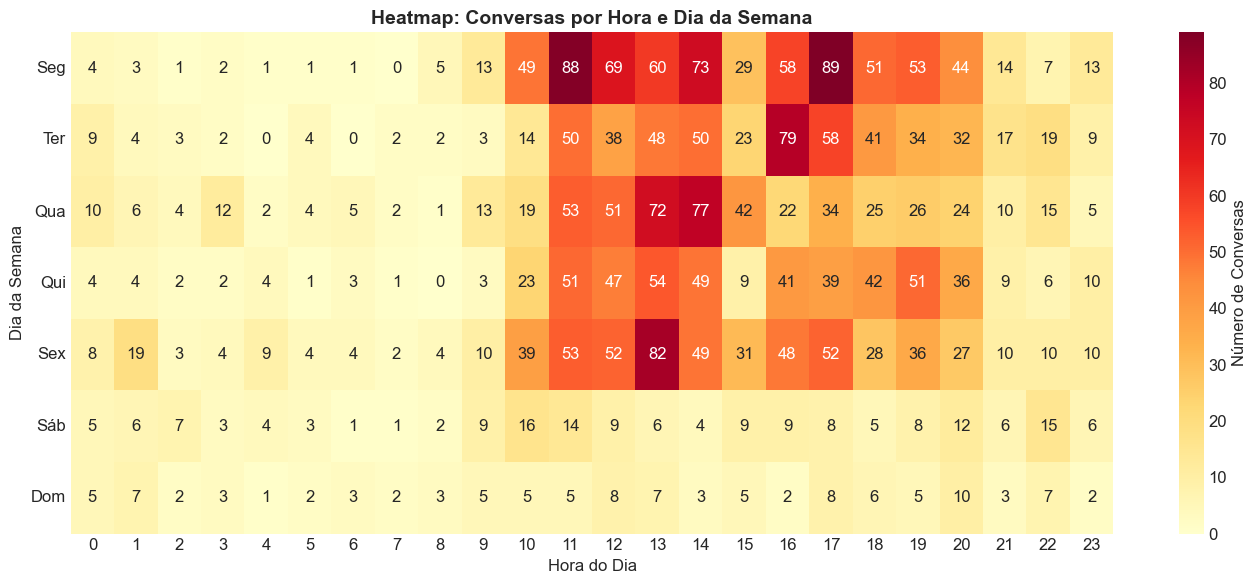

In [19]:
# Heatmap: Hora x Dia da Semana
if 'hora' in df.columns and 'dia_semana' in df.columns:
    heatmap_data = df.groupby(['dia_semana', 'hora']).size().unstack(fill_value=0)
    
    # Reordenar dias da semana
    ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    heatmap_data = heatmap_data.reindex(ordem_dias)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='d', 
                ax=ax, cbar_kws={'label': 'Número de Conversas'})
    ax.set_xlabel('Hora do Dia')
    ax.set_ylabel('Dia da Semana')
    ax.set_title('Heatmap: Conversas por Hora e Dia da Semana', fontsize=14, fontweight='bold')
    ax.set_yticklabels(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'], rotation=0)
    plt.tight_layout()
    plt.show()

## 9. Análise do Conteúdo das Conversas

In [20]:
# Verificar estrutura do campo 'content'
if 'content' in df.columns:
    print("=" * 80)
    print("ANÁLISE DO CAMPO 'CONTENT'")
    print("=" * 80)
    
    # Tamanho do conteúdo
    df['content_length'] = df['content'].astype(str).str.len()
    
    print(f"\nEstatísticas do tamanho do conteúdo (caracteres):")
    print(f"  - Média: {df['content_length'].mean():,.0f}")
    print(f"  - Mediana: {df['content_length'].median():,.0f}")
    print(f"  - Mínimo: {df['content_length'].min():,}")
    print(f"  - Máximo: {df['content_length'].max():,}")
    print(f"  - Desvio Padrão: {df['content_length'].std():,.0f}")

ANÁLISE DO CAMPO 'CONTENT'

Estatísticas do tamanho do conteúdo (caracteres):
  - Média: 31,964
  - Mediana: 7,875
  - Mínimo: 712
  - Máximo: 914,855
  - Desvio Padrão: 97,375


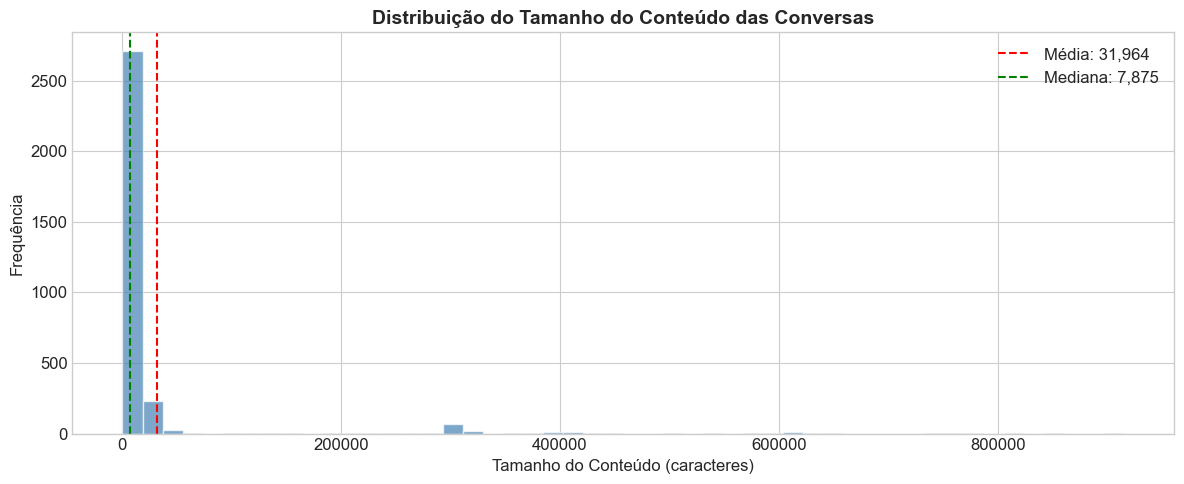

In [21]:
# Histograma do tamanho do conteúdo
if 'content_length' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(df['content_length'], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    ax.axvline(df['content_length'].mean(), color='red', linestyle='--', label=f'Média: {df["content_length"].mean():,.0f}')
    ax.axvline(df['content_length'].median(), color='green', linestyle='--', label=f'Mediana: {df["content_length"].median():,.0f}')
    ax.set_xlabel('Tamanho do Conteúdo (caracteres)')
    ax.set_ylabel('Frequência')
    ax.set_title('Distribuição do Tamanho do Conteúdo das Conversas', fontsize=14, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [22]:
# Tentar parsear o conteúdo JSON para extrair informações
def parse_content(content_str):
    """Tenta parsear o conteúdo como JSON e extrair informações."""
    try:
        if pd.isna(content_str):
            return None
        content = json.loads(content_str)
        return content
    except:
        return None

# Verificar se o conteúdo é JSON
if 'content' in df.columns:
    sample_content = df['content'].iloc[0]
    parsed = parse_content(sample_content)
    
    if parsed:
        print("O conteúdo parece ser JSON. Estrutura do primeiro registro:")
        print(f"\nChaves disponíveis: {list(parsed.keys()) if isinstance(parsed, dict) else 'Lista'}")
    else:
        print("O conteúdo não é JSON válido ou está em outro formato.")
        print(f"\nAmostra do conteúdo (primeiros 500 caracteres):")
        print(str(sample_content)[:500])

O conteúdo parece ser JSON. Estrutura do primeiro registro:

Chaves disponíveis: ['activities']


In [23]:
# Extrair número de mensagens por conversa (se o conteúdo for JSON)
def count_messages(content_str):
    """Conta o número de mensagens em uma conversa."""
    try:
        if pd.isna(content_str):
            return 0
        content = json.loads(content_str)
        
        # Tentar diferentes estruturas possíveis
        if isinstance(content, list):
            return len(content)
        elif isinstance(content, dict):
            if 'activities' in content:
                return len(content['activities'])
            elif 'messages' in content:
                return len(content['messages'])
        return 1
    except:
        return 0

if 'content' in df.columns:
    df['num_messages'] = df['content'].apply(count_messages)
    
    if df['num_messages'].sum() > 0:
        print("\nEstatísticas do número de mensagens por conversa:")
        print(f"  - Total de mensagens: {df['num_messages'].sum():,}")
        print(f"  - Média por conversa: {df['num_messages'].mean():.1f}")
        print(f"  - Mediana por conversa: {df['num_messages'].median():.1f}")
        print(f"  - Máximo por conversa: {df['num_messages'].max()}")
        print(f"  - Mínimo por conversa: {df['num_messages'].min()}")


Estatísticas do número de mensagens por conversa:
  - Total de mensagens: 61,207
  - Média por conversa: 19.3
  - Mediana por conversa: 16.0
  - Máximo por conversa: 119
  - Mínimo por conversa: 3


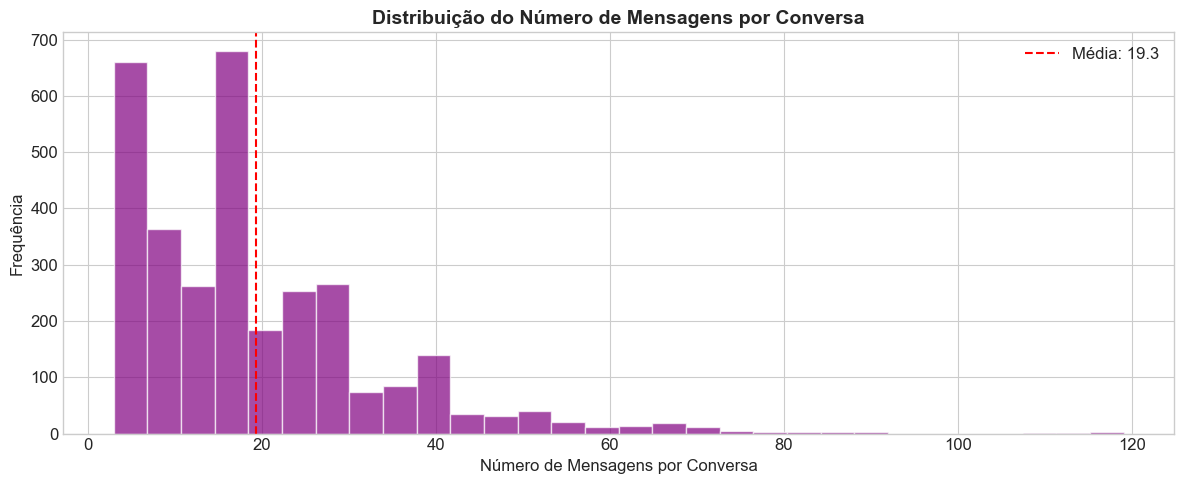

In [24]:
# Distribuição do número de mensagens
if 'num_messages' in df.columns and df['num_messages'].sum() > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(df['num_messages'], bins=30, color='purple', edgecolor='white', alpha=0.7)
    ax.axvline(df['num_messages'].mean(), color='red', linestyle='--', 
               label=f'Média: {df["num_messages"].mean():.1f}')
    ax.set_xlabel('Número de Mensagens por Conversa')
    ax.set_ylabel('Frequência')
    ax.set_title('Distribuição do Número de Mensagens por Conversa', fontsize=14, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 10. Análise de Status


DISTRIBUIÇÃO DE STATUSCODE


,Contagem,Percentual (%)
statuscode,,
1,3165,100.0


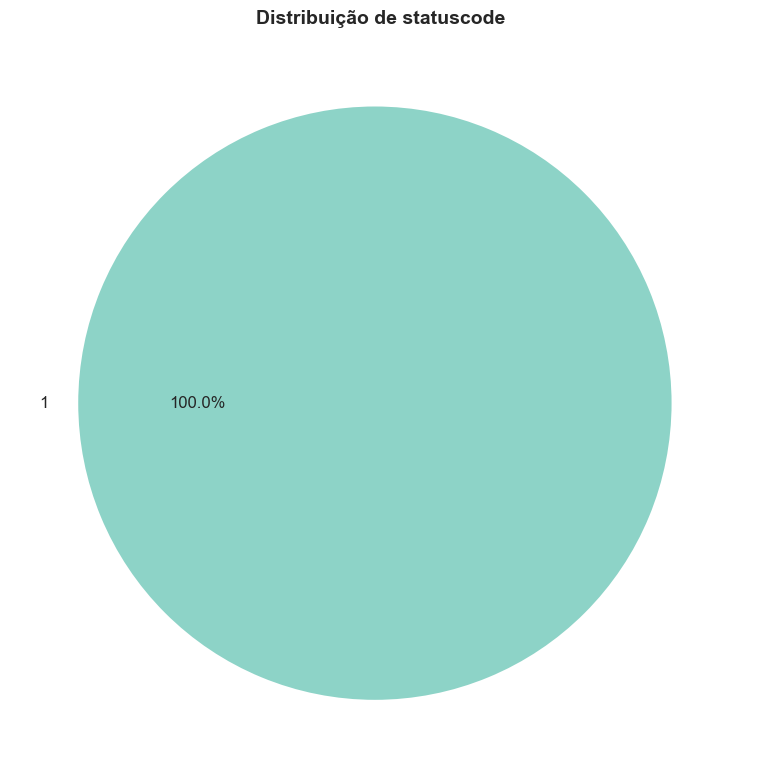


DISTRIBUIÇÃO DE STATECODE


,Contagem,Percentual (%)
statecode,,
0,3165,100.0


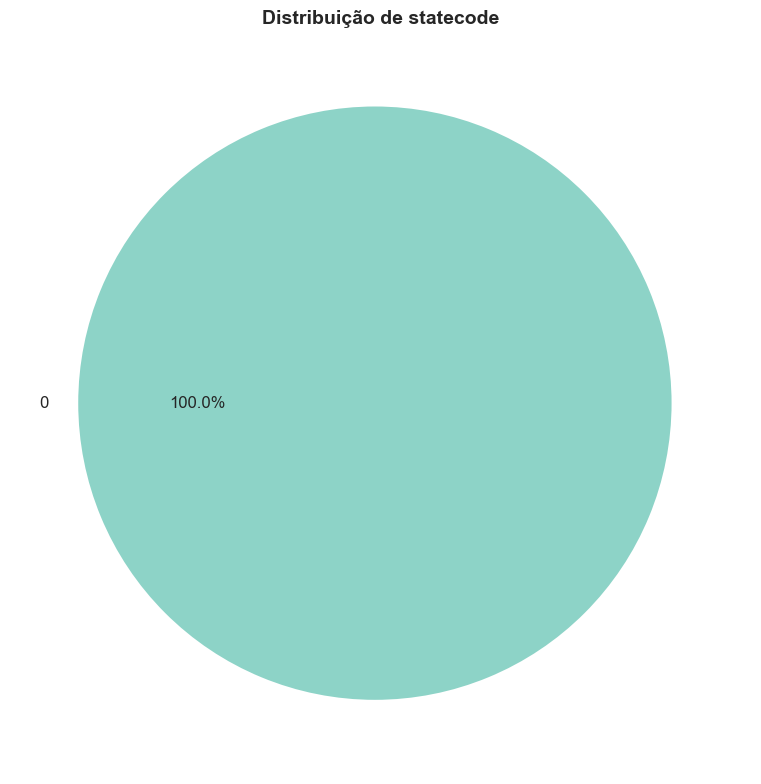

In [25]:
# Análise de statuscode e statecode
status_cols = ['statuscode', 'statecode']

for col in status_cols:
    if col in df.columns:
        print(f"\n{'=' * 60}")
        print(f"DISTRIBUIÇÃO DE {col.upper()}")
        print(f"{'=' * 60}")
        
        value_counts = df[col].value_counts(dropna=False)
        value_percent = (value_counts / len(df) * 100).round(2)
        
        status_df = pd.DataFrame({
            'Contagem': value_counts,
            'Percentual (%)': value_percent
        })
        display(status_df)
        
        # Gráfico de pizza se houver poucos valores
        if len(value_counts) <= 10:
            fig, ax = plt.subplots(figsize=(8, 8))
            colors = plt.cm.Set3(np.linspace(0, 1, len(value_counts)))
            wedges, texts, autotexts = ax.pie(value_counts.values, 
                                               labels=value_counts.index,
                                               autopct='%1.1f%%',
                                               colors=colors,
                                               explode=[0.02] * len(value_counts))
            ax.set_title(f'Distribuição de {col}', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()

## 11. Análise de Duplicados

In [26]:
# Verificar duplicados
print("=" * 80)
print("ANÁLISE DE DUPLICADOS")
print("=" * 80)

duplicados_total = df.duplicated().sum()
print(f"\nLinhas duplicadas (considerando todas as colunas): {duplicados_total}")
print(f"Percentual: {(duplicados_total / len(df) * 100):.2f}%")

# Verificar duplicados por coluna ID
id_cols = ['conversationtranscriptid', 'name']

for col in id_cols:
    if col in df.columns:
        duplicados_col = df[col].duplicated().sum()
        print(f"\nDuplicados na coluna '{col}': {duplicados_col}")

ANÁLISE DE DUPLICADOS

Linhas duplicadas (considerando todas as colunas): 0
Percentual: 0.00%

Duplicados na coluna 'conversationtranscriptid': 0

Duplicados na coluna 'name': 985


## 12. Correlações (Variáveis Numéricas)

Colunas numéricas para correlação: ['utcconversiontimezonecode', 'importsequencenumber', 'timezoneruleversionnumber', 'statuscode', 'statecode', 'versionnumber', 'content_length', 'num_messages']


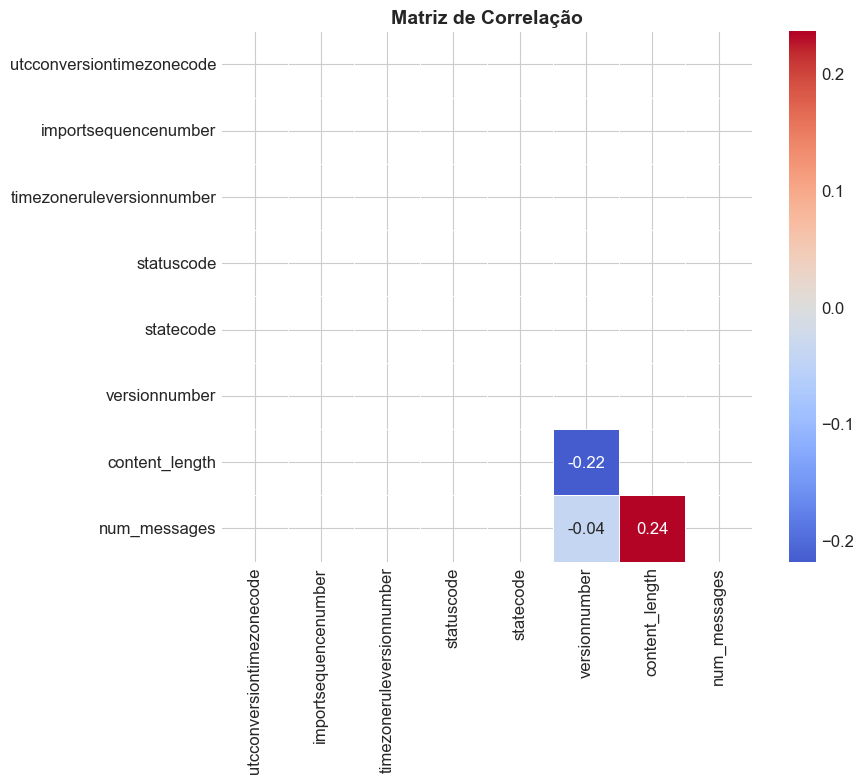

In [27]:
# Matriz de correlação para variáveis numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remover colunas auxiliares criadas
cols_to_exclude = ['ano', 'mes', 'hora']
numeric_cols = [col for col in numeric_cols if col not in cols_to_exclude]

if len(numeric_cols) > 1:
    print(f"Colunas numéricas para correlação: {numeric_cols}")
    
    corr_matrix = df[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                fmt='.2f', ax=ax, square=True, linewidths=0.5)
    ax.set_title('Matriz de Correlação', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Não há colunas numéricas suficientes para análise de correlação.")

## 13. Resumo Executivo

In [28]:
print("="*80)
print("RESUMO EXECUTIVO DA ANÁLISE EXPLORATÓRIA")
print("="*80)

print(f"\n📊 DIMENSÕES DO DATASET")
print(f"   - Total de registros: {len(df):,}")
print(f"   - Total de colunas: {len(df.columns)}")

print(f"\n📅 PERÍODO DOS DADOS")
if 'conversationstarttime' in df.columns:
    print(f"   - Data inicial: {df['conversationstarttime'].min()}")
    print(f"   - Data final: {df['conversationstarttime'].max()}")
    if df['conversationstarttime'].dtype == 'datetime64[ns]':
        print(f"   - Período total: {(df['conversationstarttime'].max() - df['conversationstarttime'].min()).days} dias")

print(f"\n🔍 QUALIDADE DOS DADOS")
total_nulos = df.isnull().sum().sum()
total_celulas = df.shape[0] * df.shape[1]
print(f"   - Células vazias: {total_nulos:,} ({(total_nulos/total_celulas*100):.2f}%)")
print(f"   - Linhas duplicadas: {duplicados_total:,}")

print(f"\n💬 ESTATÍSTICAS DAS CONVERSAS")
if 'content_length' in df.columns:
    print(f"   - Tamanho médio do conteúdo: {df['content_length'].mean():,.0f} caracteres")
if 'num_messages' in df.columns and df['num_messages'].sum() > 0:
    print(f"   - Média de mensagens por conversa: {df['num_messages'].mean():.1f}")

print(f"\n✅ Análise concluída!")

RESUMO EXECUTIVO DA ANÁLISE EXPLORATÓRIA

📊 DIMENSÕES DO DATASET
   - Total de registros: 3,165
   - Total de colunas: 22

📅 PERÍODO DOS DADOS
   - Data inicial: 2026-01-02 00:46:22
   - Data final: 2026-02-02 20:15:47
   - Período total: 31 dias

🔍 QUALIDADE DOS DADOS
   - Células vazias: 6,330 (9.09%)
   - Linhas duplicadas: 0

💬 ESTATÍSTICAS DAS CONVERSAS
   - Tamanho médio do conteúdo: 31,964 caracteres
   - Média de mensagens por conversa: 19.3

✅ Análise concluída!
